In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import classification_logistic
from importlib import reload
reload(classification_logistic)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pickle
import re

In [13]:
#load spam data 
spam_data=pd.read_csv("spam.csv",encoding="latin-1")

In [14]:
spam_data.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [19]:
#map output to numerical value
message=spam_data["v2"]
y=spam_data["v1"]
y=y.map({"ham":0,"spam":1})



0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: v2, Length: 5572, dtype: object

In [20]:
#Convert text messages into TF-IDF feature vectors
tfid=TfidfVectorizer()
X=tfid.fit_transform(message)

In [21]:
#split data in to train,validation and test data 
x_train,x_,y_train,y_=train_test_split(X,y,test_size=0.4,random_state=55)
x_val,x_test,y_val,y_test=train_test_split(x_,y_,test_size=0.5,random_state=55)

In [22]:
#list of degree to be evalaute 
degrees=[1,2,3,4,5]

In [23]:
#list of min split to be evalaute 
min_split_size=[10,20,100,20,300,400,500,600,700]

In [24]:
#define list of accuracy of train and validation data 
accuracy_train=[]
accuracy_val=[]
#choose best min split size in randomforest
for min_split in min_split_size:

    ##Initialize  model and  train it
    model=RandomForestClassifier(min_samples_split=min_split,random_state=1234).fit(x_train,y_train)

    #predict on train and vlaidation data 
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)

    #find accuracy of train and validation data
    acc_train=accuracy_score(y_train,y_train_predict)
    acc_val=accuracy_score(y_val,y_val_predict)

    #add to list 
    accuracy_train.append(acc_train)
    accuracy_val.append(acc_val)


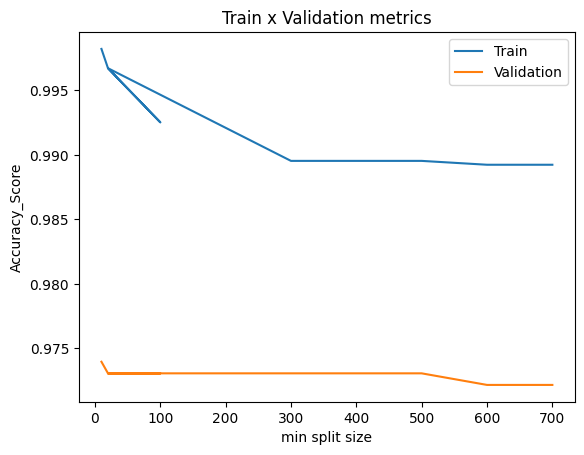

In [25]:
#plot graph pf train and validation accuracy
plt.plot(min_split_size,accuracy_train)
plt.plot(min_split_size,accuracy_val)
plt.ylabel('Accuracy_Score')
plt.xlabel('min split size')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [27]:
#find index with max val accuracy
index=np.argmax(accuracy_val)
min_split=min_split_size[index]
min_split

10

In [28]:
#list of max
max_depth_list=[2,4,8,16,32,64,100,128,200,None]



In [29]:
#define list of accuracy of train and validation data 
accuracy_train_list=[]
accuracy_val_list=[]

#find optimal max depth that suit best on Random Forest
for depth_max in max_depth_list:

    #train model on Random Forest
    model=RandomForestClassifier(max_depth=depth_max,min_samples_split=min_split,random_state=1234)
    model.fit(x_train,y_train)

    #predict on train and validation
    y_train_cap=model.predict(x_train)
    y_val_cap=model.predict(x_val)

    #find accuracy and to list
    accuracy_train_list.append(accuracy_score(y_train,y_train_cap))
    accuracy_val_list.append(accuracy_score(y_val,y_val_cap))

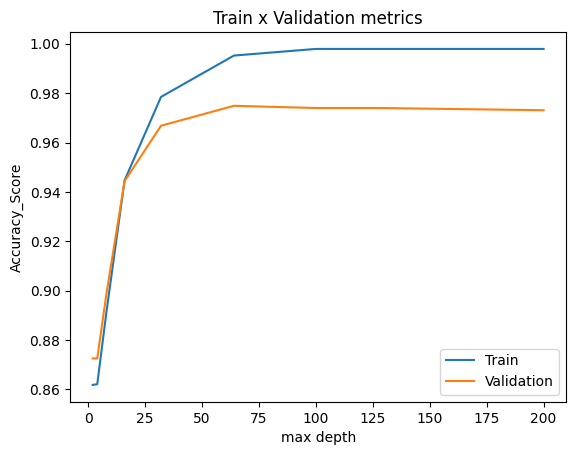

In [30]:
#plot graph of train and validation accuracy
plt.plot(max_depth_list,accuracy_train_list)
plt.plot(max_depth_list,accuracy_val_list)
plt.ylabel('Accuracy_Score')
plt.xlabel('max depth')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [31]:
#find optimal max depth
index=np.argmax(accuracy_val_list)
max_depth=max_depth_list[index]
max_depth

64

In [32]:
#list of all estimator list
n_estimator_list=[10,100,200,300,400]


In [33]:
#define list of accuracy
accuracy_train_list=[]
accuracy_val_list=[]
for n_estimator in n_estimator_list:
    model=RandomForestClassifier(n_estimators=n_estimator,min_samples_split=min_split,max_depth=max_depth)
    model.fit(x_train,y_train)
    y_train_predict=model.predict(x_train)
    y_val_predict=model.predict(x_val)
    accuracy_train_list.append(accuracy_score(y_train,y_train_predict))
    accuracy_val_list.append(accuracy_score(y_val,y_val_predict))
    


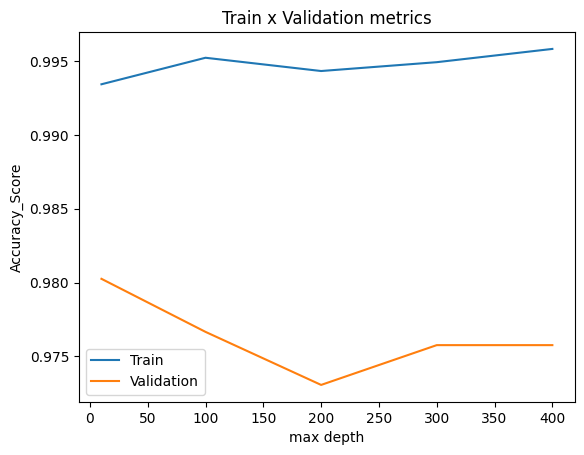

In [34]:
#plot graph pf train and validation accuracy
plt.plot(n_estimator_list,accuracy_train_list)
plt.plot(n_estimator_list,accuracy_val_list)
plt.ylabel('Accuracy_Score')
plt.xlabel('max depth')
plt.title('Train x Validation metrics')
plt.legend(['Train','Validation'])

In [36]:
#find optimal n estimator from list
index=np.argmax(accuracy_val_list)
n_estimator=n_estimator_list[index]
n_estimator

10

In [37]:
#train Random Forest on train data with optimal hyper parameter
model=RandomForestClassifier(n_estimators=n_estimator,min_samples_split=min_split,max_depth=max_depth)
model.fit(x_train,y_train)


,n_estimators,10
,criterion,'gini'
,max_depth,64
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
# Save the trained model as a pickle file for future predictions
pickle.dump(model,open("spam_tree_ensemble.pkl","wb"))